Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


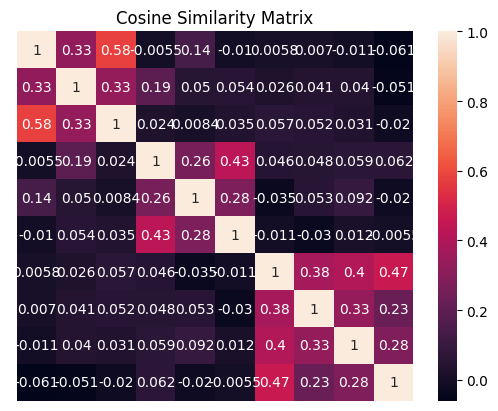


Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

Sentence: The bowler delivered a fast yorker
Similarity Score: 0.5414



In [2]:
# ================================
# Part 4 — Vector DB (Embeddings Demo)
# ================================

# Install required library
!pip install sentence-transformers seaborn matplotlib scikit-learn

# Imports
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ================================
# 1. Create Sentences (3 Topics)
# ================================

sentences = [
    # Cricket
    "The batsman scored a century in the final match",
    "The bowler delivered a fast yorker",
    "The team won the cricket tournament",

    # Cooking
    "The chef prepared a delicious pasta dish",
    "Baking requires precise measurements of ingredients",
    "The recipe includes spices and herbs",

    # Cybersecurity
    "Cybersecurity protects systems from hackers",
    "Encryption secures sensitive data",
    "Phishing attacks trick users into giving information",
    "Firewalls help prevent unauthorized access"
]

# ================================
# 2. Generate Embeddings
# ================================

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

# ================================
# 3. Cosine Similarity Matrix
# ================================

similarity_matrix = cosine_similarity(embeddings)

# ================================
# 4. Plot Heatmap
# ================================

plt.figure()
sns.heatmap(similarity_matrix, annot=True, xticklabels=False, yticklabels=False)
plt.title("Cosine Similarity Matrix")
plt.show()

# ================================
# 5. Query Similarity
# ================================

query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 matches
top_indices = np.argsort(similarities)[-2:][::-1]

print("\nQuery:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")